# PropertyTax Training and Model Selection

This notebook cleans the PropertyTax dataset, builds a classification-ready training table, compares several models, tunes the best one, and saves the final artifacts.

The training target is `is_late_payment` because `tax_amount` is almost fully determined by `assessed_value * tax_rate` in this dataset.

In [6]:
%pip install matplotlib numpy pandas seaborn scikit-learn

  Using cached matplotlib-3.10.9-cp314-cp314-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scikit_learn-1.8.0-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp314-cp314-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached scipy-1.17.1-cp314-cp314-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached matplotlib-3.10.9-cp314-cp314-win_amd64.whl (8.3 MB)
   ---------------------------------------- 0.0/12.5 MB ? eta -:--:--
   ------------------

In [ ]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.4f}'.format)

In [12]:
RAW_PATH = Path('../datasets/PropertyTax.csv')
CLEAN_PATH = Path('../datasets/PropertyTax_cleaned.csv')
PROCESSED_PATH = Path('../datasets/PropertyTax_model_ready.csv')
ARTIFACTS_DIR = Path('../models')
ARTIFACTS_DIR.mkdir(exist_ok=True)


def normalize_title_case(series):
    cleaned = series.fillna('').astype(str).str.replace('-', ' ', regex=False)
    cleaned = cleaned.str.split().str.join(' ')
    return cleaned.str.title()


def clean_property_tax_dataset(frame):
    cleaned = frame.copy()
    cleaned = cleaned.drop_duplicates(subset=['record_id'], keep='first').copy()
    cleaned['province'] = normalize_title_case(cleaned['province'])
    cleaned['property_type'] = normalize_title_case(cleaned['property_type'])
    unit_no = cleaned['unit_no'].fillna('').astype(str).str.strip()
    cleaned['unit_no'] = unit_no.mask(unit_no.eq('') | unit_no.str.lower().eq('nan'), 'N/A')
    return cleaned


df_raw = pd.read_csv(RAW_PATH)
df = clean_property_tax_dataset(df_raw)
df.to_csv(CLEAN_PATH, index=False)

print(f'Raw rows: {len(df_raw):,}')
print(f'Rows after duplicate removal: {len(df):,}')
print(f'Duplicates removed: {len(df_raw) - len(df):,}')
df.head()

Raw rows: 5,280
Rows after duplicate removal: 5,000
Duplicates removed: 280


,record_id,owner_id,taxpayer_type,owner_name,tin,mailing_address,mailing_city,mailing_province,property_id,pin,tax_declaration_no,province,city_municipality,barangay,property_address,property_type,class_code,zoning_classification,land_use,lot_number,unit_no,lot_area_sqm,market_value,assessment_level,assessed_value,tax_rate,tax_amount,assessment_year,due_date,years_as_owner,prior_assessments,prior_late_payments,prior_unpaid_payments,avg_previous_delay_days,outstanding_balance,payment_compliance_score,is_late_payment
0,9,1359,Company,AgriNova Farms Enterprises,459-477-213-000,"123 Lacson St, Matina Pangi, City of Davao",City of Davao,Davao Del Sur,5,11-000-000-000005,TD-11-2024-000005,Davao Del Sur,CITY OF DIGOS,Soong,"576 Maa Road, Soong, City of Digos",Commercial,COM-01,Commercial Zone,Retail / Office,LOT-00005,N/A,292,"3,249,602.0000",0.5000,"1,624,801.0000",0.0145,"23,559.6100",2023,2023-03-31,7,6,1,1,33.1000,"10,167.7900",66.2600,0
1,1581,417,Individual,Danica I. Mendoza,517-651-619-000,"174 Diversion Road, Barangay 40-D (Pob.), City...",City of Davao,Davao Del Sur,791,11-000-000-000791,TD-11-2024-000791,Davao Del Norte,Island Garden City of Samal,Limao,"817 Cabaguio Ave, Limao, Island Garden City of...",Commercial,COM-01,Commercial Zone,Retail / Office,LOT-00791,N/A,632,"6,948,462.0900",0.5000,"3,474,231.0400",0.0138,"47,944.3900",2021,2021-03-31,11,8,2,1,44.6000,"35,123.7700",40.0900,1
2,545,92,Individual,Rafael I. Gonzales,192-676-344-000,"322 Lacson St, Aumbay, Island Garden City of S...",Island Garden City of Samal,Davao Del Norte,273,11-000-000-000273,TD-11-2024-000273,Davao Del Sur,City of Davao,Sirawan,"349 Matina Aplaya Road, Sirawan, City of Davao",Agricultural,AGR-01,Agricultural Zone,Crop / Orchard Land,LOT-00273,N/A,1839,"2,229,071.7200",0.4000,"891,628.6900",0.0130,"11,591.1700",2021,2021-09-30,4,3,1,0,13.4000,"1,286.3200",90.1300,0
3,4887,1506,Company,Apo Township Enterprises,606-918-242-000,"82 Cabaguio Ave, Abnate, Kiblawan",Kiblawan,Davao Del Sur,2444,11-000-000-002444,TD-11-2024-002444,Davao Del Norte,City of Tagum,Bincungan,"9 Lanang Road, Bincungan, City of Tagum",Commercial,COM-01,Commercial Zone,Retail / Office,LOT-02444,N/A,265,"3,078,049.9400",0.5000,"1,539,024.9700",0.0164,"25,240.0100",2023,2023-12-31,12,8,2,1,36.2000,"13,495.0000",60.1700,0
4,3942,711,Individual,Paolo B. Carreon,811-533-677-000,"621 Quimpo Blvd, Kimlawis, Kiblawan",Kiblawan,Davao Del Sur,1971,11-000-000-001971,TD-11-2024-001971,Davao Del Sur,City of Davao,Barangay 24-C (Pob.),"81 Bonifacio St, Barangay 24-C (Pob.), City of...",Agricultural,AGR-01,Agricultural Zone,Crop / Orchard Land,LOT-01971,N/A,4566,"6,352,728.8400",0.4000,"2,541,091.5400",0.0118,"29,984.8800",2022,2022-06-30,16,8,4,1,85.9000,"22,502.7400",6.8300,1


In [13]:
print('---------------- INFO ---------------------\n')
print(df.info(), '\n')

print('------------ DESCRIBE -------------\n')
print(df.describe(), '\n')

print('------------- NULL VALUES -----------\n')
print(df.isna().sum(), '\n')

print('------------- DUPLICATE record_id -----------\n')
print(df['record_id'].duplicated().sum(), '\n')

formula_gap = (df['tax_amount'] - (df['assessed_value'] * df['tax_rate'])).abs()
print('------------- TAX FORMULA CHECK -----------\n')
print(f'Max absolute gap: {formula_gap.max():.4f}')
print(f'Mean absolute gap: {formula_gap.mean():.4f}')

print('------------- TARGET BALANCE -----------\n')
print(df['is_late_payment'].value_counts())
print(df['is_late_payment'].value_counts(normalize=True), '\n')

---------------- INFO ---------------------

<class 'pandas.DataFrame'>
Index: 5000 entries, 0 to 5279
Data columns (total 37 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   record_id                 5000 non-null   int64  
 1   owner_id                  5000 non-null   int64  
 2   taxpayer_type             5000 non-null   str    
 3   owner_name                5000 non-null   str    
 4   tin                       5000 non-null   str    
 5   mailing_address           5000 non-null   str    
 6   mailing_city              5000 non-null   str    
 7   mailing_province          5000 non-null   str    
 8   property_id               5000 non-null   int64  
 9   pin                       5000 non-null   str    
 10  tax_declaration_no        5000 non-null   str    
 11  province                  5000 non-null   object 
 12  city_municipality         5000 non-null   str    
 13  barangay                  5000 non

In [14]:
df['due_date'] = pd.to_datetime(df['due_date'], errors='coerce')
df['due_month'] = df['due_date'].dt.month
df['due_quarter'] = df['due_date'].dt.quarter
df['log_market_value'] = np.log1p(df['market_value'])
df['log_assessed_value'] = np.log1p(df['assessed_value'])
df['log_outstanding_balance'] = np.log1p(df['outstanding_balance'])

drop_columns = [
    'record_id',
    'owner_id',
    'owner_name',
    'tin',
    'mailing_address',
    'property_id',
    'pin',
    'tax_declaration_no',
    'property_address',
    'lot_number',
    'due_date',
]

model_df = df.drop(columns=drop_columns).copy()
model_df['is_late_payment'] = model_df['is_late_payment'].astype(int)
model_df.to_csv(PROCESSED_PATH, index=False)

print(model_df.columns.tolist())
model_df.head()

['taxpayer_type', 'mailing_city', 'mailing_province', 'province', 'city_municipality', 'barangay', 'property_type', 'class_code', 'zoning_classification', 'land_use', 'unit_no', 'lot_area_sqm', 'market_value', 'assessment_level', 'assessed_value', 'tax_rate', 'tax_amount', 'assessment_year', 'years_as_owner', 'prior_assessments', 'prior_late_payments', 'prior_unpaid_payments', 'avg_previous_delay_days', 'outstanding_balance', 'payment_compliance_score', 'is_late_payment', 'due_month', 'due_quarter', 'log_market_value', 'log_assessed_value', 'log_outstanding_balance']


,taxpayer_type,mailing_city,mailing_province,province,city_municipality,barangay,property_type,class_code,zoning_classification,land_use,unit_no,lot_area_sqm,market_value,assessment_level,assessed_value,tax_rate,tax_amount,assessment_year,years_as_owner,prior_assessments,prior_late_payments,prior_unpaid_payments,avg_previous_delay_days,outstanding_balance,payment_compliance_score,is_late_payment,due_month,due_quarter,log_market_value,log_assessed_value,log_outstanding_balance
0,Company,City of Davao,Davao Del Sur,Davao Del Sur,CITY OF DIGOS,Soong,Commercial,COM-01,Commercial Zone,Retail / Office,N/A,292,"3,249,602.0000",0.5000,"1,624,801.0000",0.0145,"23,559.6100",2023,7,6,1,1,33.1000,"10,167.7900",66.2600,0,3.0000,1.0000,14.9940,14.3009,9.2271
1,Individual,City of Davao,Davao Del Sur,Davao Del Norte,Island Garden City of Samal,Limao,Commercial,COM-01,Commercial Zone,Retail / Office,N/A,632,"6,948,462.0900",0.5000,"3,474,231.0400",0.0138,"47,944.3900",2021,11,8,2,1,44.6000,"35,123.7700",40.0900,1,3.0000,1.0000,15.7540,15.0609,10.4667
2,Individual,Island Garden City of Samal,Davao Del Norte,Davao Del Sur,City of Davao,Sirawan,Agricultural,AGR-01,Agricultural Zone,Crop / Orchard Land,N/A,1839,"2,229,071.7200",0.4000,"891,628.6900",0.0130,"11,591.1700",2021,4,3,1,0,13.4000,"1,286.3200",90.1300,0,9.0000,3.0000,14.6171,13.7008,7.1603
3,Company,Kiblawan,Davao Del Sur,Davao Del Norte,City of Tagum,Bincungan,Commercial,COM-01,Commercial Zone,Retail / Office,N/A,265,"3,078,049.9400",0.5000,"1,539,024.9700",0.0164,"25,240.0100",2023,12,8,2,1,36.2000,"13,495.0000",60.1700,0,12.0000,4.0000,14.9398,14.2467,9.5101
4,Individual,Kiblawan,Davao Del Sur,Davao Del Sur,City of Davao,Barangay 24-C (Pob.),Agricultural,AGR-01,Agricultural Zone,Crop / Orchard Land,N/A,4566,"6,352,728.8400",0.4000,"2,541,091.5400",0.0118,"29,984.8800",2022,16,8,4,1,85.9000,"22,502.7400",6.8300,1,6.0000,2.0000,15.6644,14.7481,10.0214


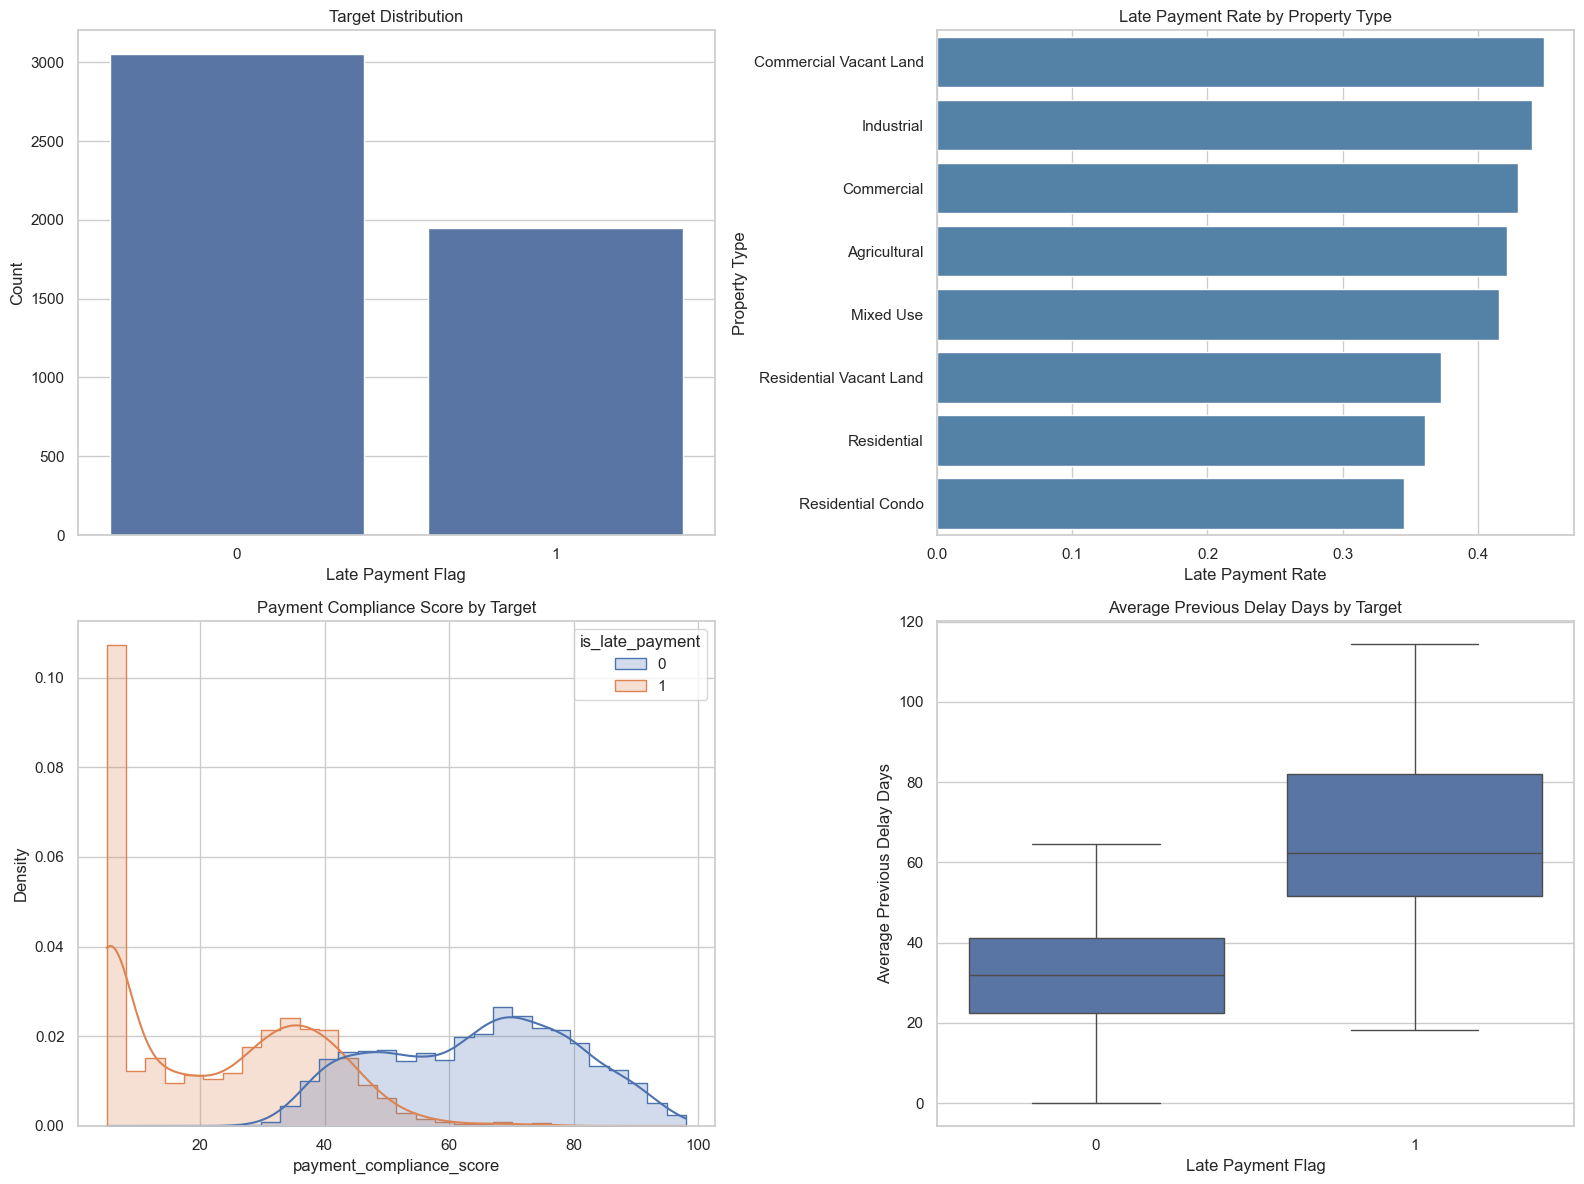

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.countplot(data=model_df, x='is_late_payment', ax=axes[0, 0])
axes[0, 0].set_title('Target Distribution')
axes[0, 0].set_xlabel('Late Payment Flag')
axes[0, 0].set_ylabel('Count')

late_rate_by_type = model_df.groupby('property_type')['is_late_payment'].mean().sort_values(ascending=False)
sns.barplot(x=late_rate_by_type.values, y=late_rate_by_type.index, ax=axes[0, 1], color='steelblue')
axes[0, 1].set_title('Late Payment Rate by Property Type')
axes[0, 1].set_xlabel('Late Payment Rate')
axes[0, 1].set_ylabel('Property Type')

sns.histplot(data=model_df, x='payment_compliance_score', hue='is_late_payment', bins=30, kde=True, ax=axes[1, 0], element='step', stat='density', common_norm=False)
axes[1, 0].set_title('Payment Compliance Score by Target')

sns.boxplot(data=model_df, x='is_late_payment', y='avg_previous_delay_days', ax=axes[1, 1])
axes[1, 1].set_title('Average Previous Delay Days by Target')
axes[1, 1].set_xlabel('Late Payment Flag')
axes[1, 1].set_ylabel('Average Previous Delay Days')

plt.tight_layout()
plt.show()

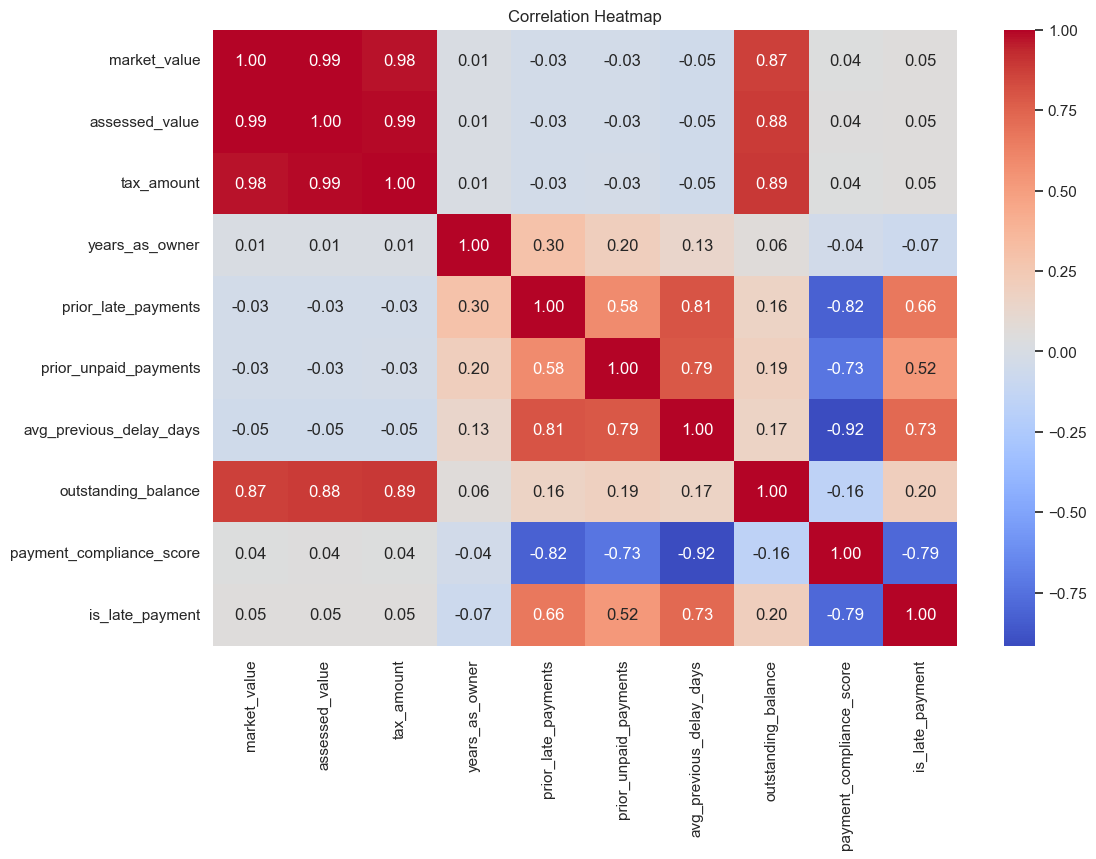

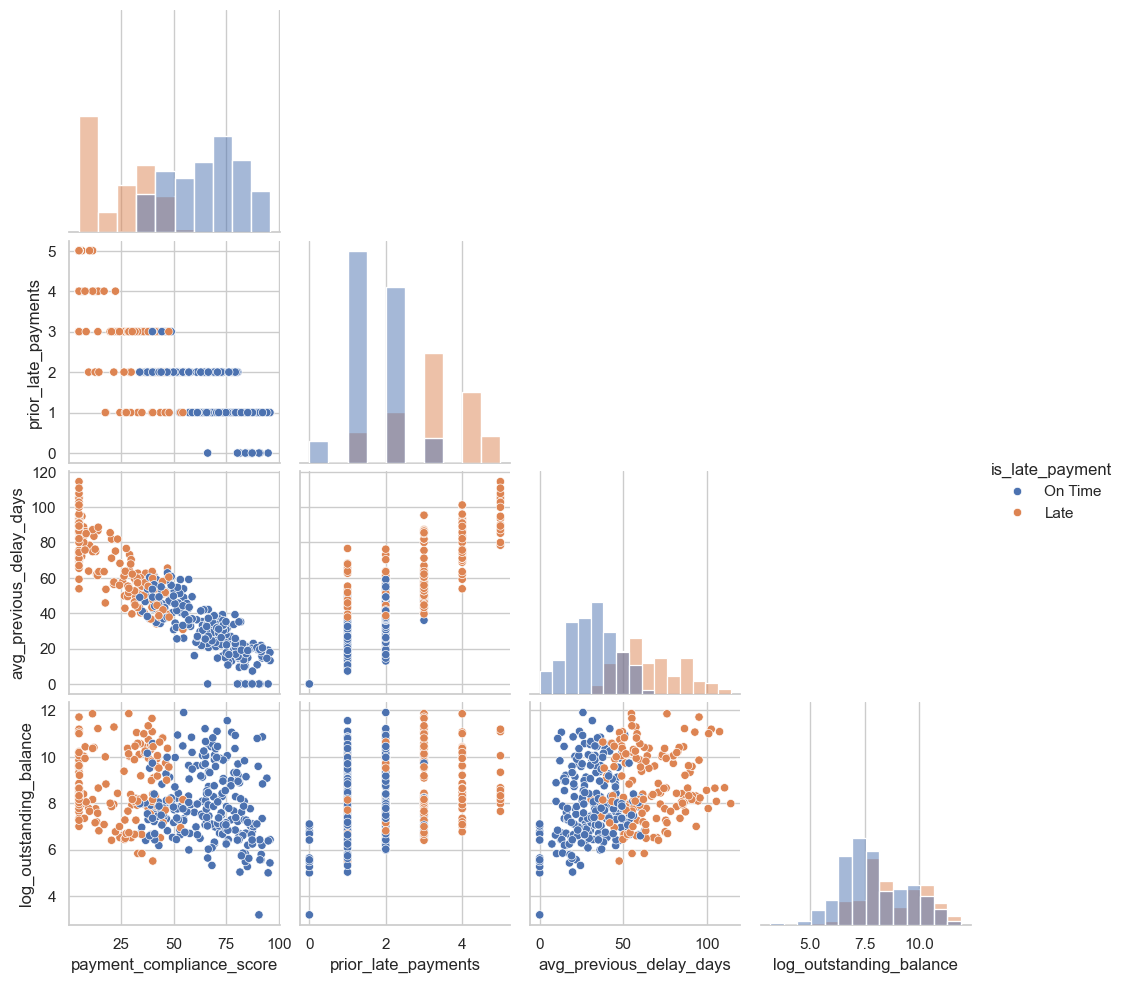

In [16]:
corr_columns = [
    'market_value',
    'assessed_value',
    'tax_amount',
    'years_as_owner',
    'prior_late_payments',
    'prior_unpaid_payments',
    'avg_previous_delay_days',
    'outstanding_balance',
    'payment_compliance_score',
    'is_late_payment',
]

plt.figure(figsize=(12, 8))
sns.heatmap(model_df[corr_columns].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

pairplot_columns = [
    'payment_compliance_score',
    'prior_late_payments',
    'avg_previous_delay_days',
    'log_outstanding_balance',
    'is_late_payment',
]

pairplot_sample = model_df[pairplot_columns].sample(n=min(400, len(model_df)), random_state=42).copy()
pairplot_sample['is_late_payment'] = pairplot_sample['is_late_payment'].map({0: 'On Time', 1: 'Late'})
sns.pairplot(pairplot_sample, hue='is_late_payment', corner=True, diag_kind='hist')
plt.show()

In [ ]:
target_column = 'is_late_payment'
X = model_df.drop(columns=[target_column])
y = model_df[target_column]

categorical_features = X.select_dtypes(include=['object', 'string']).columns.tolist()
numeric_features = X.select_dtypes(exclude=['object', 'string']).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore')),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_features),
        ('num', numeric_transformer, numeric_features),
    ]
)

print('Categorical features:', categorical_features)
print('Numeric features:', numeric_features)
print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)

In [ ]:
model_builders = {
    'Logistic Regression': lambda: LogisticRegression(max_iter=2000, class_weight='balanced'),
    'Random Forest': lambda: RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1,
    ),
    'Extra Trees': lambda: ExtraTreesClassifier(
        n_estimators=300,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1,
    ),
}

baseline_results = []
fitted_models = {}

for model_name, model_builder in model_builders.items():
    pipeline = Pipeline(
        steps=[
            ('preprocess', preprocess),
            ('model', model_builder()),
        ]
    )
    cv_scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring='roc_auc',
        n_jobs=1,
    )
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_score = pipeline.predict_proba(X_test)[:, 1]

    baseline_results.append(
        {
            'model': model_name,
            'cv_roc_auc_mean': cv_scores.mean(),
            'cv_roc_auc_std': cv_scores.std(),
            'test_accuracy': accuracy_score(y_test, y_pred),
            'test_precision': precision_score(y_test, y_pred, zero_division=0),
            'test_recall': recall_score(y_test, y_pred, zero_division=0),
            'test_f1': f1_score(y_test, y_pred, zero_division=0),
            'test_roc_auc': roc_auc_score(y_test, y_score),
        }
    )
    fitted_models[model_name] = pipeline

results_df = pd.DataFrame(baseline_results).sort_values(
    ['test_roc_auc', 'test_f1', 'test_accuracy'],
    ascending=False,
).reset_index(drop=True)

results_df

In [ ]:
best_model_name = results_df.loc[0, 'model']
best_baseline_model = fitted_models[best_model_name]

print(f'Best baseline model: {best_model_name}')

plt.figure(figsize=(10, 7))
for model_name, pipeline in fitted_models.items():
    y_score = pipeline.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc_score = roc_auc_score(y_test, y_score)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC={auc_score:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('ROC Curves for Baseline Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

ConfusionMatrixDisplay.from_estimator(best_baseline_model, X_test, y_test, cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()

In [ ]:
param_grids = {
    'Logistic Regression': {
        'model__C': [0.1, 1.0, 3.0],
        'model__class_weight': [None, 'balanced'],
    },
    'Random Forest': {
        'model__n_estimators': [200, 400],
        'model__max_depth': [None, 16],
        'model__min_samples_split': [2, 8],
        'model__min_samples_leaf': [1, 2],
        'model__max_features': ['sqrt', 0.6],
    },
    'Extra Trees': {
        'model__n_estimators': [200, 400],
        'model__max_depth': [None, 16],
        'model__min_samples_split': [2, 8],
        'model__min_samples_leaf': [1, 2],
        'model__max_features': ['sqrt', 0.6],
    },
}

search_pipeline = Pipeline(
    steps=[
        ('preprocess', preprocess),
        ('model', model_builders[best_model_name]()),
    ]
)

grid = GridSearchCV(
    estimator=search_pipeline,
    param_grid=param_grids[best_model_name],
    cv=5,
    scoring='roc_auc',
    n_jobs=1,
    verbose=0,
)

grid.fit(X_train, y_train)
best_model = grid.best_estimator_

print('Best Params:', grid.best_params_)
print('Best CV ROC AUC:', grid.best_score_)

In [ ]:
y_pred = best_model.predict(X_test)
y_score = best_model.predict_proba(X_test)[:, 1]

print('\n=== Test Metrics ===')
print('Accuracy:', accuracy_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred, zero_division=0))
print('Recall:', recall_score(y_test, y_pred, zero_division=0))
print('F1:', f1_score(y_test, y_pred, zero_division=0))
print('ROC AUC:', roc_auc_score(y_test, y_score))
print('\n=== Classification Report ===')
print(classification_report(y_test, y_pred, zero_division=0))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues', ax=axes[0])
axes[0].set_title('Tuned Model Confusion Matrix')

fpr, tpr, _ = roc_curve(y_test, y_score)
axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_score):.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[1].set_title('Tuned Model ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

precision, recall, _ = precision_recall_curve(y_test, y_score)
axes[2].plot(recall, precision, color='darkorange')
axes[2].set_title('Precision-Recall Curve')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')

plt.tight_layout()
plt.show()

In [ ]:
estimator = best_model.named_steps['model']
feature_names = best_model.named_steps['preprocess'].get_feature_names_out()

if hasattr(estimator, 'feature_importances_'):
    importance_values = estimator.feature_importances_
else:
    importance_values = np.abs(estimator.coef_[0])

feature_importance_df = (
    pd.DataFrame(
        {
            'feature': feature_names,
            'importance': importance_values,
        }
    )
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance_df.head(15), x='importance', y='feature', color='steelblue')
plt.title(f'Top 15 Features - {best_model_name}')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

selection_results_path = ARTIFACTS_DIR / 'propertytax_model_selection_results.csv'
model_path = ARTIFACTS_DIR / f"{best_model_name.lower().replace(' ', '_')}_propertytax_model.pkl"
feature_info_path = ARTIFACTS_DIR / 'propertytax_feature_info.json'

results_df.to_csv(selection_results_path, index=False)
joblib.dump(best_model, model_path)

feature_info = {
    'target': target_column,
    'best_model_name': best_model_name,
    'categorical_features': categorical_features,
    'numeric_features': numeric_features,
    'all_features': list(X.columns),
    'best_params': grid.best_params_,
}
with feature_info_path.open('w', encoding='utf-8') as file:
    json.dump(feature_info, file, indent=4)

print(feature_importance_df.head(15))
print(f'Model selection results saved to: {selection_results_path.resolve()}')
print(f'Best model saved to: {model_path.resolve()}')
print(f'Feature info saved to: {feature_info_path.resolve()}')